# Hate Speech Detection with Machine Learning
Social media platforms face a significant challenge with hate speech content appearing regularly on platforms such as Twitter and Facebook. Content containing hate speech often originates from accounts with strong political affiliations. This project demonstrates how to build and train a machine learning model for automated hate speech detection using Python.

<div align="center">
<img src="https://i0.wp.com/cjp.org.in/wp-content/uploads/2018/01/Hate-Speech-FE-Legal-Resource.png?fit=1020%2C534&ssl=1" />
</div>

## Understanding Hate Speech
While there isn't a universally accepted legal definition of hate speech due to the subjective nature of classifying opinions as harmful or offensive, the United Nations provides a comprehensive definition. According to the UN, hate speech encompasses any form of communication—whether spoken, written, or behavioral—that targets individuals or groups with discriminatory language based on characteristics such as religion, ethnicity, nationality, race, color, ancestry, gender, or other identity factors.

## Project Overview
Now that we understand what constitutes hate speech, it's clear that social media platforms must implement systems to identify and mitigate such content before it spreads widely or causes harm. This project will guide you through developing a machine learning solution for hate speech detection using Python. The dataset used in this project can be accessed [here](https://raw.githubusercontent.com/amankharwal/Website-data/master/twitter.csv).

## 1. Importing Libraries
First, let's import the necessary libraries for data manipulation, visualization, and machine learning.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import html
import re
import nltk
import neattext as ntx
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import lightgbm as lgb
import joblib

import warnings

### Configuration
Let's configure the necessary settings.
- Ignore warnings for cleaner output.
- Set default figure size to 12x8 inches for plots.
- Use seaborn's 'darkgrid' style for improved plot aesthetics.

In [11]:
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style('darkgrid')

## 2. Data Loading
Next, we will read the dataset from the URL and take a quick look at its structure.

In [12]:
df = pd.read_csv('https://raw.githubusercontent.com/amankharwal/Website-data/master/twitter.csv', index_col=0)

In [13]:
df.head()

,count,hate_speech,offensive_language,neither,class,tweet
0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24783 entries, 0 to 25296
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   count               24783 non-null  int64 
 1   hate_speech         24783 non-null  int64 
 2   offensive_language  24783 non-null  int64 
 3   neither             24783 non-null  int64 
 4   class               24783 non-null  int64 
 5   tweet               24783 non-null  object
dtypes: int64(5), object(1)
memory usage: 1.3+ MB


## 3. Exploratory Data Analysis
Let's take a closer look at the data to understand its distribution and relationships.

In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
count,24783.0,3.243473,0.883060,3.0,3.0,3.0,3.0,9.0
hate_speech,24783.0,0.280515,0.631851,0.0,0.0,0.0,0.0,7.0
offensive_language,24783.0,2.413711,1.399459,0.0,2.0,3.0,3.0,9.0
neither,24783.0,0.549247,1.113299,0.0,0.0,0.0,0.0,9.0
class,24783.0,1.110277,0.462089,0.0,1.0,1.0,1.0,2.0


In [16]:
df.isnull().sum()

count                 0
hate_speech           0
offensive_language    0
neither               0
class                 0
tweet                 0
dtype: int64

Now, I will add a new column to this dataset as labels which will contain the values as:
1. Hate Speech 
2. Offensive Language 
3. No Hate and Offensive

In [17]:
df['label'] = df['class'].map({
    0: 'Hate Speech',
    1: 'Offensive Language',
    2: 'No Hate and Offensive'
})

In [18]:
df = df[['tweet', 'label', 'class']]

In [19]:
df.head()

,tweet,label,class
0,!!! RT @mayasolovely: As a woman you shouldn't...,No Hate and Offensive,2
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,Offensive Language,1
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,Offensive Language,1
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,Offensive Language,1
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,Offensive Language,1


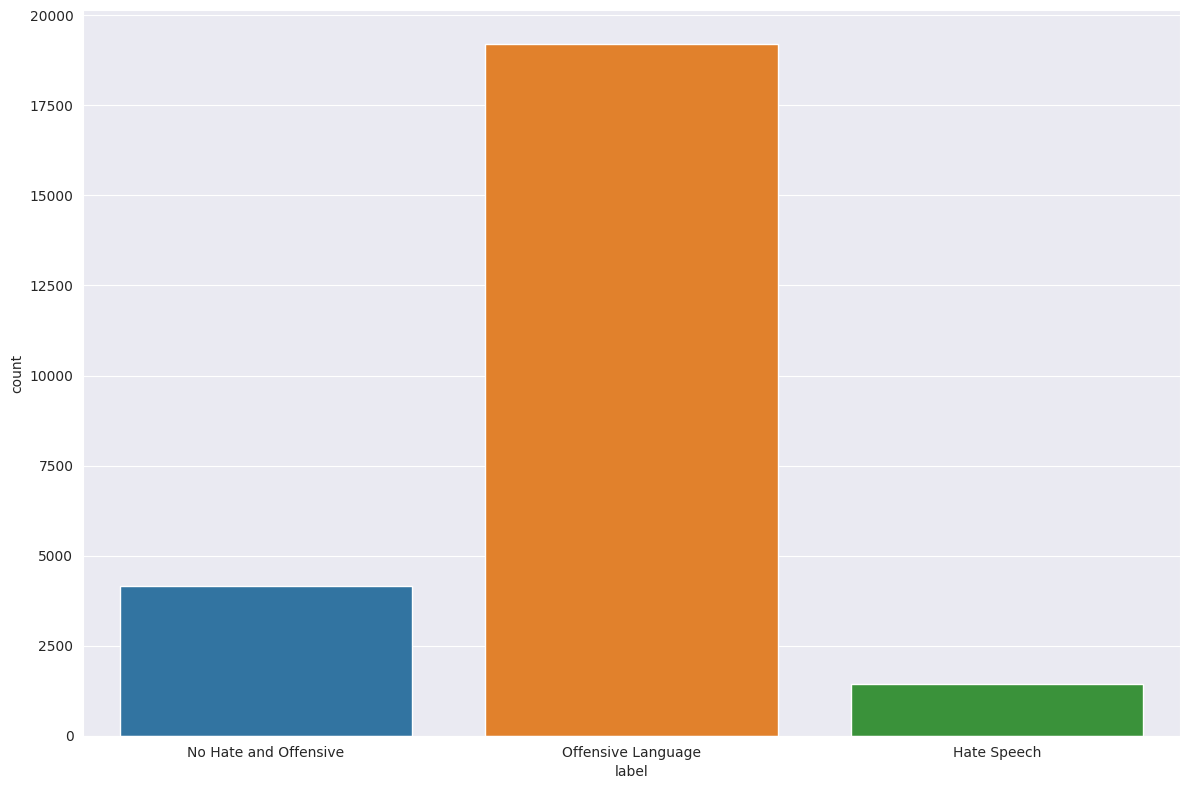

In [20]:
sns.countplot(df, x='label', hue='label')
plt.tight_layout()

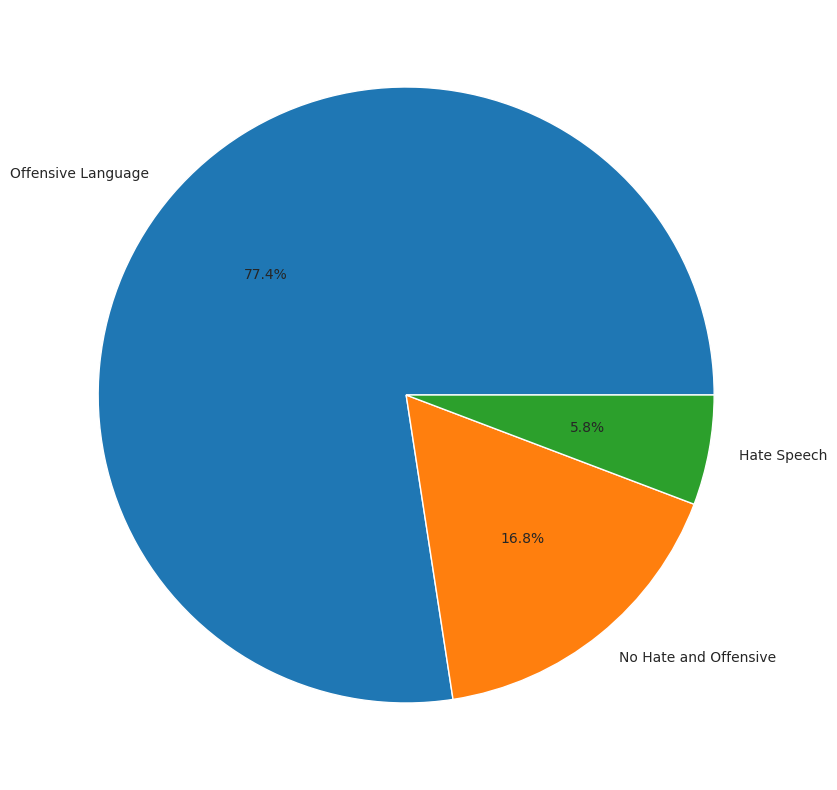

In [21]:
df.label.value_counts().plot.pie(autopct='%1.1f%%')
plt.ylabel('')
plt.tight_layout()

## 4. Data Preprocessing
Let's preprocess the data to make it ready for the machine learning model.

In [22]:
stemmer = nltk.SnowballStemmer('english')

In [23]:
# Function to clean the text
def clean_text(text):
    text = text.lower()
    text = re.sub('@\w+', '', text)
    text = ntx.remove_urls(text)
    text = html.unescape(text)
    text = ntx.clean_text(text)
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = re.sub('\s{2,}', ' ', text)
    text = ntx.remove_stopwords(text)
    text = ' '.join([stemmer.stem(word) for word in text.split()])
    text = re.sub(r'\brt\b', '', text)

    return text

df.tweet.apply(clean_text)

0                      woman complain clean hous man trash
1         boy dat coldtyga dwn bad cuffin dat hoe 1st p...
2                   dawg  fuck bitch start cri confus shit
3                                         look like tranni
4                       shit hear true faker bitch told ya
                               ...                        
25291    yous muthafin lie right tl trash bibl scriptur...
25292      gone broke wrong heart babi drove redneck crazi
25294    young buck wanna eat dat nigguh like aint fuck...
25295                       youu got wild bitch tellin lie
25296    ruffl ntac eileen dahlia beauti color combin p...
Name: tweet, Length: 24783, dtype: object

In [24]:
# Let's apply the clean_text function to the tweet column
df['tweet_clean'] = df['tweet'].apply(clean_text)

In [25]:
df.head()

,tweet,label,class,tweet_clean
0,!!! RT @mayasolovely: As a woman you shouldn't...,No Hate and Offensive,2,woman complain clean hous man trash
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,Offensive Language,1,boy dat coldtyga dwn bad cuffin dat hoe 1st p...
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,Offensive Language,1,dawg fuck bitch start cri confus shit
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,Offensive Language,1,look like tranni
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,Offensive Language,1,shit hear true faker bitch told ya


Let's split the data as x and y.

In [26]:
x = np.array(df['tweet_clean'])
y = np.array(df['class'])

Let's vectorize the text data using TfidfVectorizer. TfidfVectorizer converts a collection of raw documents into a matrix of TF-IDF features. TF-IDF is a numerical statistic that reflects how important a word is to a document in a collection or corpus.

In [27]:
vectorizer = TfidfVectorizer()
x_vect = vectorizer.fit_transform(x)

In [28]:
x_vect.shape

(24783, 17495)

Let's split the data into training and testing sets.

In [29]:
x_train, x_test, y_train, y_test = train_test_split(x_vect, y, test_size=0.2, random_state=42)

## 5. Modeling
Let's train a machine learning model to classify the text data. I will use LightGBM for this task. LightGBM is a gradient boosting framework that uses tree-based learning algorithms.

In [30]:
model = lgb.LGBMClassifier(verbose=-1)

In [31]:
%%time
model.fit(x_train, y_train)

CPU times: user 8.34 s, sys: 56 ms, total: 8.4 s
Wall time: 1.95 s


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [32]:
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print(f'Accuracy  : {accuracy}')
print(f'Precision : {precision}')
print(f'Recall    : {recall}')
print(f'F1 Score  : {f1}')

Accuracy  : 0.9017550938067379
Precision : 0.7563008921053506
Recall    : 0.6905455269002704
F1 Score  : 0.6982638445189545


## 6. Save the model
Let's build a pipeline to save the model.

In [33]:
pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer()),
    ('model', lgb.LGBMClassifier(verbose=-1))
])
pipeline.fit(x, y)

,steps,"[('vectorizer', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [34]:
y_pred = pipeline.predict(x)

<Axes: >

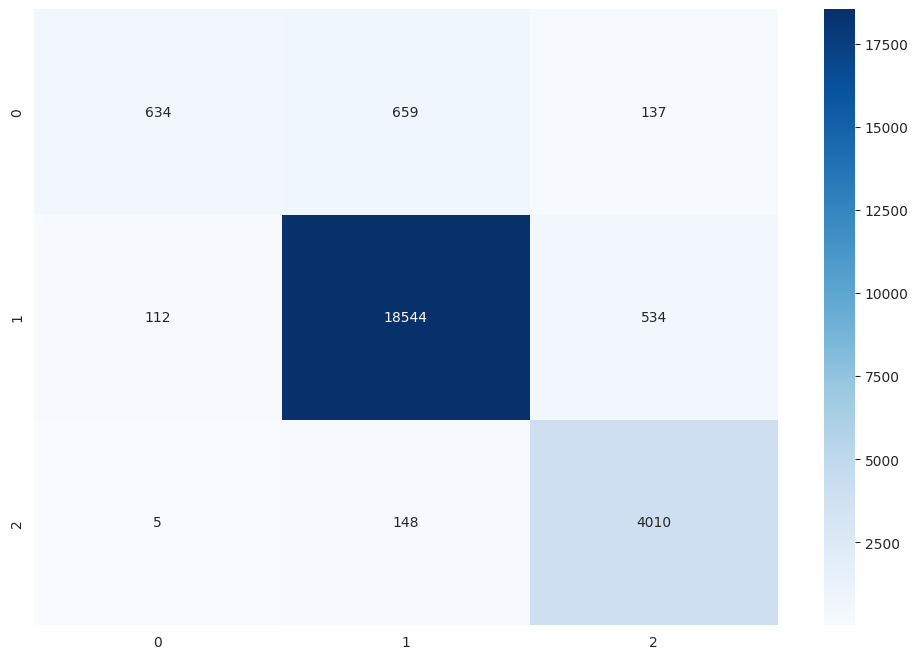

In [35]:
sns.heatmap(confusion_matrix(y, y_pred), annot=True, fmt='d', cmap='Blues')

In [36]:
print(classification_report(y, y_pred, target_names=['Hate Speech', 'Offensive Language', 'No Hate and Offensive']))

                       precision    recall  f1-score   support

          Hate Speech       0.84      0.44      0.58      1430
   Offensive Language       0.96      0.97      0.96     19190
No Hate and Offensive       0.86      0.96      0.91      4163

             accuracy                           0.94     24783
            macro avg       0.89      0.79      0.82     24783
         weighted avg       0.93      0.94      0.93     24783



In [37]:
joblib.dump(pipeline, 'hate_speech_detection.pkl')

['hate_speech_detection.pkl']

## 7. Conclusion
This project built an end-to-end hate speech detection pipeline: data loading, cleaning (token normalization, stopword removal, stemming), TF‑IDF vectorization, model training with LightGBM, evaluation, and model serialization.

**Key insights:**
- Traditional TF‑IDF + tree‑based models achieve strong baseline performance on social media text.
- Careful text cleaning (e.g., removing mentions/URLs, handling contractions, stemming) materially improves signal-to-noise.
- Class imbalance and overlapping categories ("Hate Speech" vs "Offensive Language") can affect precision/recall per class.

**Future improvements:**
- Experiment with transformer embeddings (e.g., BERT, RoBERTa) and class-weighted losses.
- Add robust evaluation: stratified CV, per-class metrics, ROC/PR curves, and calibration.
- Address imbalance with techniques like focal loss or resampling; refine labels with better guidelines.
- Deploy an inference API with input sanitation and SHAP-based explanations for moderation workflows.
- Continuous monitoring and periodic re-training to combat dataset and concept drift.